# Evaluación 1: Análisis Exploratorio de Datos (EDA)
**Integrantes**
- Priscila Rodriguez
- Rocio Saavedra
- Fiorela Osorio
- Darío Garcia

**Fecha:** Lunes 27 de Abril

**Asignatura:** Mineria de Datos



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

In [11]:
# URL directa del archivo
url = 'https://raw.githubusercontent.com/Darygarav/base-de-datos-australia/main/weatherAUS.csv'

# Carga el dataset
df = pd.read_csv(url)

print("Carga exitosa")
df.head()

Carga exitosa


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [12]:
print("\n" + "=" * 60)
print("INFORMACIÓN GENERAL (dtypes + nulos)")
print("=" * 60)
df.info()


INFORMACIÓN GENERAL (dtypes + nulos)
<class 'pandas.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  str    
 1   Location       142193 non-null  str    
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  str    
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  str    
 10  WindDir3pm     138415 non-null  str    
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cl

In [13]:
# ==============================================================
# a) CLASIFICACIÓN DE VARIABLES
# ==============================================================
print("\n" + "=" * 60)
print("a) CLASIFICACIÓN DE VARIABLES")
print("=" * 60)

clasificacion = {
    "Numéricas Continuas": [
        "MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine",
        "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm",
        "Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm",
        "Temp9am", "Temp3pm", "RISK_MM"
    ],
    "Numéricas Discretas": [],
    "Categóricas Nominales": ["Location", "WindGustDir", "WindDir9am", "WindDir3pm"],
    "Categóricas Ordinales": ["Cloud9am", "Cloud3pm", "Date"],  # octavos 0-8 + fecha tienen orden
    "Booleanas / Indicadoras": ["RainToday", "RainTomorrow"],
}

for tipo, cols in clasificacion.items():
    cols_presentes = [c for c in cols if c in df.columns]
    print(f"\n▶ {tipo}  ({len(cols_presentes)} variables)")
    for c in cols_presentes:
        print(f"   • {c}")


a) CLASIFICACIÓN DE VARIABLES

▶ Numéricas Continuas  (15 variables)
   • MinTemp
   • MaxTemp
   • Rainfall
   • Evaporation
   • Sunshine
   • WindGustSpeed
   • WindSpeed9am
   • WindSpeed3pm
   • Humidity9am
   • Humidity3pm
   • Pressure9am
   • Pressure3pm
   • Temp9am
   • Temp3pm
   • RISK_MM

▶ Numéricas Discretas  (0 variables)

▶ Categóricas Nominales  (4 variables)
   • Location
   • WindGustDir
   • WindDir9am
   • WindDir3pm

▶ Categóricas Ordinales  (3 variables)
   • Cloud9am
   • Cloud3pm
   • Date

▶ Booleanas / Indicadoras  (2 variables)
   • RainToday
   • RainTomorrow


### Justificación de la Clasificación de Variables

**Variables Numéricas Continuas**

*   **MinTemp, MaxTemp, Temp9am, Temp3pm**: La temperatura es una escala física que admite infinitas subdivisiones. Se puede medir con gran precisión, permitiendo valores decimales.
*   **Rainfall, RISK_MM**: Se mide en milímetros y puede haber fracciones de estos (ej. 0.5 mm). Aunque a menudo se registra como 0.0, la naturaleza subyacente de la precipitación es continua.
*   **Evaporation**: Al igual que la lluvia, es una medida de volumen/longitud sobre tiempo que permite decimales, reflejando un proceso físico continuo.
*   **Sunshine**: Aunque se mida en horas, el tiempo es una magnitud continua (pueden ser 5.4 horas de sol).
*   **WindGustSpeed, WindSpeed9am, WindSpeed3pm**: La velocidad del viento es una magnitud física continua, que puede variar gradualmente.
*   **Pres9am, Pres3pm**: La presión atmosférica se mide en una escala continua (hectopascales), donde los valores pueden ser cualquier número real dentro de un rango.

**Variables Categóricas Nominales**

*   **Location, WindGustDir, WindDir9am, WindDir3pm**: Corresponden a categorías o etiquetas que describen cualidades (como nombres de lugares o direcciones del viento). No existe un orden inherente o jerarquía entre las diferentes categorías.

**Variables Categóricas Ordinales**

*   **Date**: Es ordinal porque los días tienen una secuencia lógica temporal. Aunque también se puede tratar como continua si se convierte a formato numérico (ej. número de días desde una fecha de inicio), su naturaleza fundamental de orden cronológico la hace ordinal.
*   **Cloud9am / Cloud3pm**: Se miden en una escala de valores enteros llamados “octavos” (de 0 a 8), donde cada valor representa un nivel específico de cobertura del cielo. Existe un orden claro (0 = sin nubes, 8 = cielo cubierto) pero la diferencia entre 1 y 2 octavos no es necesariamente la misma que entre 7 y 8.

**Variables Booleanas / Indicadoras**

*   **RainToday, RainTomorrow**: Son variables binarias que solo pueden tomar dos valores: 'No' (generalmente codificado como 0) y 'Sí' (generalmente codificado como 1). Representan la ocurrencia o no de un evento (lluvia), por lo que se clasifican como booleanas.

**B) Analice la distribución de al menos tres variables numéricas relevantes mediante histogramas. ¿Presentan asimetría (sesgo)? En caso afirmativo, indique si es positiva o negativa y discuta sus implicancias en el análisis y modelamiento de los datos.**


b) HISTOGRAMAS Y ANÁLISIS DE ASIMETRÍA
  MinTemp         → Skewness = +0.024  →  Aproximadamente SIMÉTRICA
  MaxTemp         → Skewness = +0.225  →  Aproximadamente SIMÉTRICA
  Rainfall        → Skewness = +9.888  →  Asimetría POSITIVA (cola derecha)


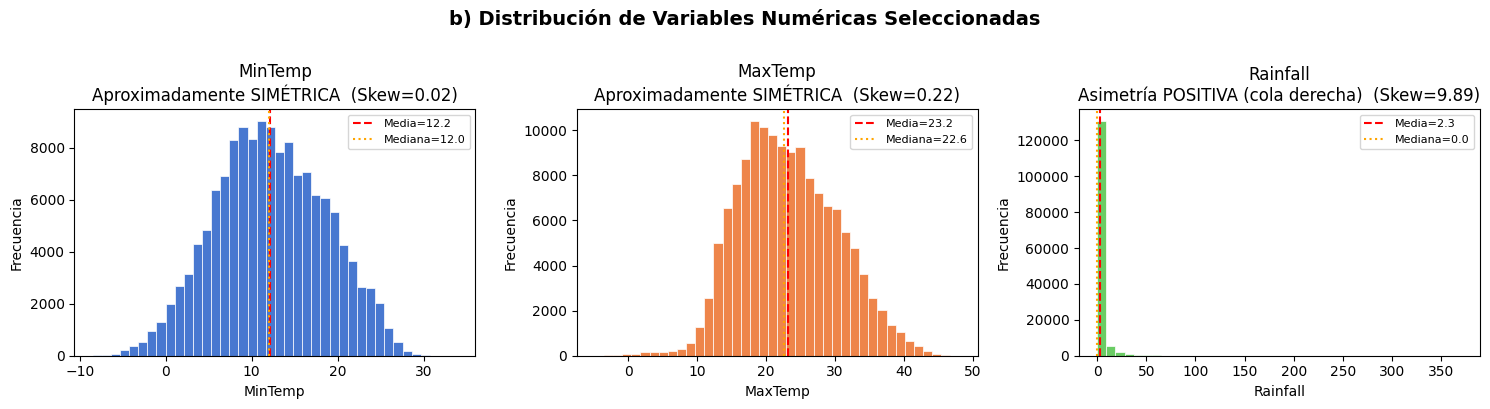

In [14]:
# ==============================================================
# b) HISTOGRAMAS Y ASIMETRÍA
# ==============================================================
print("\n" + "=" * 60)
print("b) HISTOGRAMAS Y ANÁLISIS DE ASIMETRÍA")
print("=" * 60)

vars_hist = ["MinTemp", "MaxTemp", "Rainfall"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()

for i, var in enumerate(vars_hist):
    col = df[var].dropna()
    skew = col.skew()
    tipo_sesgo = (
        "Asimetría POSITIVA (cola derecha)" if skew > 0.5
        else "Asimetría NEGATIVA (cola izquierda)" if skew < -0.5
        else "Aproximadamente SIMÉTRICA"
    )
    axes[i].hist(col, bins=40, color=sns.color_palette("muted")[i], edgecolor="white", linewidth=0.5)
    axes[i].axvline(col.mean(),   color="red",    linestyle="--", linewidth=1.5, label=f"Media={col.mean():.1f}")
    axes[i].axvline(col.median(), color="orange", linestyle=":",  linewidth=1.5, label=f"Mediana={col.median():.1f}")
    axes[i].set_title(f"{var}\n{tipo_sesgo}  (Skew={skew:.2f})")
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frecuencia")
    print(f"  {var:15s} → Skewness = {skew:+.3f}  →  {tipo_sesgo}")

plt.suptitle("b) Distribución de Variables Numéricas Seleccionadas", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("b_histogramas.png", bbox_inches="tight")
plt.show()


**Interpretación**:

*   **Rainfall** tiene una asimetría positiva muy fuerte, ya que la gran mayoria de dias no registra precipitaciones, concentrando la masa de datos en 0.
Se genera una cola muy larga que infla artificialmente la media alejandola de la realidad común. El promedio no es una medida confiable por los valores extremos (outliers)
*   **MinTemp** y **MaxTemp** ambas son aproximadamente simétricas, más adecuadas para modelos que asumen normalidad.

Temperaturas se puede modelar de forma bastante natural, pero Rainfall necesita tratamiento especial porque su asimetría indica una estructura muy distinta y más difícil de *modelar*

 **C) Calcule medidas descriptivas (media, mediana, desviación estándar, mínimo y máximo) para las variables numéricas. Interprete los resultados en términos de tendencia central y dispersión.**


c) ESTADÍSTICAS DESCRIPTIVAS
                  Media  Mediana  Desv.Est.  Mínimo  Máximo
MinTemp          12.186     12.0      6.403    -8.5    33.9
MaxTemp          23.227     22.6      7.118    -4.8    48.1
Rainfall          2.350      0.0      8.465     0.0   371.0
Evaporation       5.470      4.8      4.189     0.0   145.0
Sunshine          7.625      8.5      3.782     0.0    14.5
WindGustSpeed    39.984     39.0     13.589     6.0   135.0
WindSpeed9am     14.002     13.0      8.893     0.0   130.0
WindSpeed3pm     18.638     19.0      8.803     0.0    87.0
Humidity9am      68.844     70.0     19.051     0.0   100.0
Humidity3pm      51.483     52.0     20.798     0.0   100.0
Pressure9am    1017.654   1017.6      7.105   980.5  1041.0
Pressure3pm    1015.258   1015.2      7.037   977.1  1039.6
Cloud9am          4.437      5.0      2.887     0.0     9.0
Cloud3pm          4.503      5.0      2.721     0.0     9.0
Temp9am          16.988     16.7      6.493    -7.2    40.2
Temp3pm   

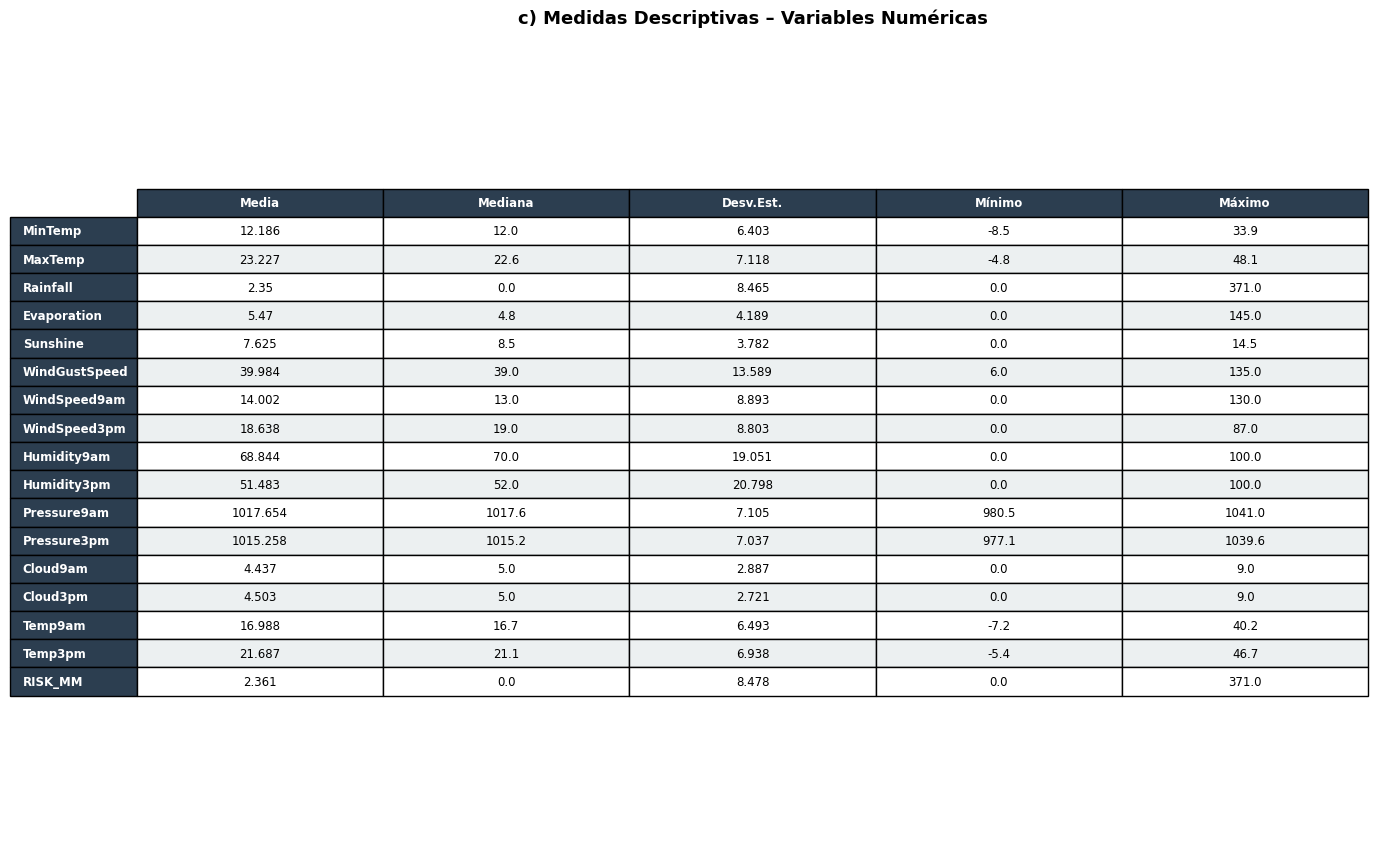

In [7]:
3# ==============================================================
# c) MEDIDAS DESCRIPTIVAS
# ==============================================================
print("\n" + "=" * 60)
print("c) ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)

num_cols = df.select_dtypes(include=np.number).columns.tolist()
desc = df[num_cols].agg(["mean", "median", "std", "min", "max"]).T
desc.columns = ["Media", "Mediana", "Desv.Est.", "Mínimo", "Máximo"]
desc = desc.round(3)
print(desc.to_string())

# Tabla visual
fig, ax = plt.subplots(figsize=(14, len(num_cols) * 0.45 + 1))
ax.axis("off")
table = ax.table(
    cellText=desc.values,
    rowLabels=desc.index,
    colLabels=desc.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.2, 1.4)
for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#ecf0f1")
plt.title("c) Medidas Descriptivas – Variables Numéricas", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("c_descriptivas.png", bbox_inches="tight")
plt.show()



**Temperatura (MinTemp, MaxTemp, Temp9am, Temp3pm)**
Las temperaturas muestran distribuciones simétricas, ya que media y mediana son muy cercanas entre sí . La desviación estándar ronda los 6-7°C, lo que indica una dispersión moderada y esperable dado que el dataset abarca múltiples regiones y estaciones del año.

**Precipitación (Rainfall) y RISK_MM**
Ambas variables presentan una fuerte discrepancia entre media y mediana, lo que es señal clara de asimetría positiva extrema. La mediana en 0 indica que más del 50% de los días no registra lluvia, mientras que la media es "arrastrada" hacia arriba por eventos de lluvia intensa. La desviación estándar es casi 4 veces la media, confirmando altísima variabilidad.
Dado que la media está tan influenciada por valores outliers, es mejor utilizar la mediana, ya que la media generaría un sesgo artificial.

**Evaporación y Sunshine**
Evaporation muestra media=5.47 y mediana=4.8, con cierta asimetría positiva moderada. Sunshine tiene media=7.6 y mediana=8.5 horas, con la mediana mayor que la media, sugiriendo leve asimetría negativa.

**Viento (WindGustSpeed, WindSpeed9am, WindSpeed3pm)**
WindGustSpeed tiene media=40 km/h y desv.est.=13.6, lo que representa un CV alto. Los mínimos en 0 de WindSpeed9am y WindSpeed3pm sugieren posibles errores de registro o días con calma absoluta.

**Humedad (Humidity9am, Humidity3pm)**
La humedad a las 9am es mayor en promedio que a las 3pm, lo cual es físicamente coherente ya que el calor del día reduce la humedad relativa. Ambas tienen desviaciones estándar altas, indicando gran variabilidad entre ubicaciones.

**Presión atmosférica (Pressure9am, Pressure3pm)**
Son las variables más estables del dataset: media ≈ 1017 hPa con desv.est. de solo 7 hPa. La diferencia entre media y mediana es mínima , indicando distribución muy simétrica. El CV sería extremadamente bajo, lo que las hace confiables para modelos.

**Nubosidad (Cloud9am, Cloud3pm)**
Con media ≈ 4.5 sobre un máximo de 9 octavos, el cielo australiano promedio está aproximadamente a mitad de cobertura. La desviación estándar de ~2.8 indica variabilidad considerable entre días.

**D) Analice la dispersión de las variables numéricas mediante la desviación estándar y
el coeficiente de variación. ¿Qué variables presentan mayor variabilidad relativa?
Discuta las implicancias de estos resultados en el modelamiento de los datos.**


d) COEFICIENTE DE VARIACIÓN (CV)
               Desv. Est.  CV (%)
Cloud3pm             2.72   60.42
Cloud9am             2.89   65.06
Evaporation          4.19   76.58
Humidity3pm         20.80   40.40
Humidity9am         19.05   27.67
MaxTemp              7.12   30.64
MinTemp              6.40   52.54
Pressure3pm          7.04    0.69
Pressure9am          7.11    0.70
RISK_MM              8.48  359.13
Rainfall             8.47  360.22
Sunshine             3.78   49.59
Temp3pm              6.94   31.99
Temp9am              6.49   38.22
WindGustSpeed       13.59   33.99
WindSpeed3pm         8.80   47.23
WindSpeed9am         8.89   63.51


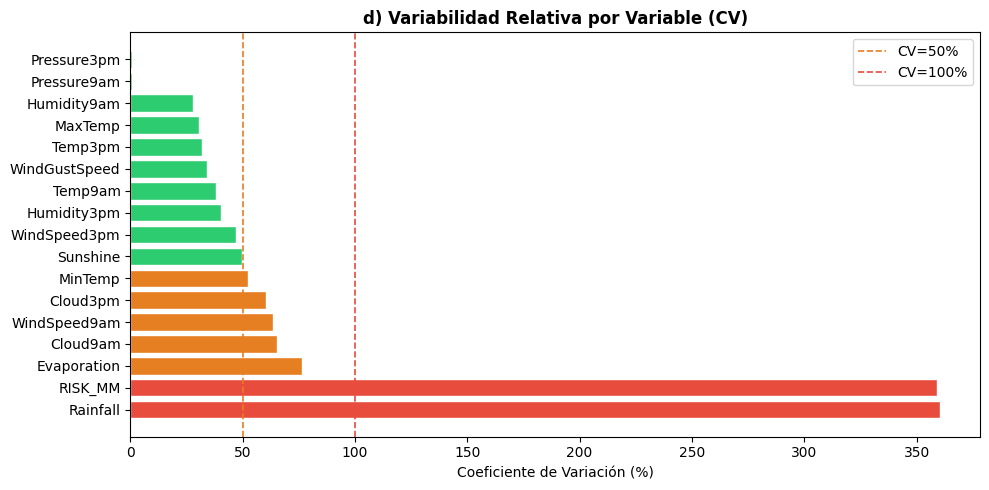


Variables con MAYOR variabilidad relativa:
  • Rainfall: CV = 360.2%
  • RISK_MM: CV = 359.1%
  • Evaporation: CV = 76.6%


In [8]:
# ==============================================================
# d) COEFICIENTE DE VARIACIÓN
# ==============================================================
print("\n" + "=" * 60)
print("d) COEFICIENTE DE VARIACIÓN (CV)")
print("=" * 60)

std_dev = df[num_cols].std().round(2)
cv = (df[num_cols].std() / df[num_cols].mean().abs() * 100).dropna().sort_values(ascending=False)
cv_df = pd.DataFrame({"Desv. Est.": std_dev, "CV (%)": cv.round(2)})
print(cv_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c" if v > 100 else "#e67e22" if v > 50 else "#2ecc71" for v in cv.values]
bars = ax.barh(cv.index, cv.values, color=colors, edgecolor="white")
ax.axvline(50,  color="#e67e22", linestyle="--", linewidth=1.2, label="CV=50%")
ax.axvline(100, color="#e74c3c", linestyle="--", linewidth=1.2, label="CV=100%")
ax.set_xlabel("Coeficiente de Variación (%)")
ax.set_title("d) Variabilidad Relativa por Variable (CV)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("d_cv.png", bbox_inches="tight")
plt.show()

top3 = cv.head(3)
print("\nVariables con MAYOR variabilidad relativa:")
for var, val in top3.items():
    print(f"  • {var}: CV = {val:.1f}%")


### Interpretación del Coeficiente de Variación (CV)

El Coeficiente de Variación (CV) es una medida de dispersión relativa que expresa la desviación estándar como porcentaje de la media. Permite comparar la variabilidad de conjuntos de datos con medias muy diferentes.

**Variables con Mayor Variabilidad Relativa (CV Alto):**

*   **Rainfall (CV = 360.22%) y RISK_MM (CV = 359.13%):** Estas variables muestran una variabilidad extremadamente alta. Esto se debe a la gran cantidad de días sin lluvia (mediana de 0) y a la existencia de eventos de lluvia muy intensos. Su comportamiento es muy impredecible y no sigue una distribución normal haciendo que sea la información más inestable que tenemos.

*   **Evaporation (CV = 76.58%):** También presenta una alta variabilidad, esto nos dice que aunque hay un patrón los datos están muy dispersos, indicando que los niveles de evaporación son bastante inconsistentes a lo largo del tiempo o en diferentes ubicaciones.

*   **Cloud9am (CV = 65.06%), WindSpeed9am (CV = 63.51%), Cloud3pm (CV = 60.42%):** Estas variables también exhiben una variabilidad significativa, lo que sugiere fluctuaciones importantes en la nubosidad y la velocidad del viento.

**Implicancias para el Modelado:**

Las variables con un Coeficiente de Variación muy alto, como `Rainfall` y `RISK_MM`, pueden **dominar** los modelos de machine learning que son sensibles a la escala o a la distancia . Su gran rango de valores y su alta dispersión pueden hacer que estos modelos les den una importancia desproporcionada.
En las variables con coeficiente de variación mayor a 100% la desviación estandar es más grande que el promedio, significando que el promedio no describe la realidad de los datos.


E) Analice la presencia de valores faltantes en el dataset. ¿Qué variables presentan
mayor cantidad de datos faltantes? ¿Qué implicancias tiene esto para el análisis
posterior?


e) ANÁLISIS DE VALORES FALTANTES
               Nulos  % Faltante
Sunshine       67816       47.69
Evaporation    60843       42.79
Cloud3pm       57094       40.15
Cloud9am       53657       37.74
Pressure9am    14014        9.86
Pressure3pm    13981        9.83
WindDir9am     10013        7.04
WindGustDir     9330        6.56
WindGustSpeed   9270        6.52
WindDir3pm      3778        2.66
Humidity3pm     3610        2.54
Temp3pm         2726        1.92
WindSpeed3pm    2630        1.85
Humidity9am     1774        1.25
Rainfall        1406        0.99
RainToday       1406        0.99
WindSpeed9am    1348        0.95
Temp9am          904        0.64
MinTemp          637        0.45
MaxTemp          322        0.23


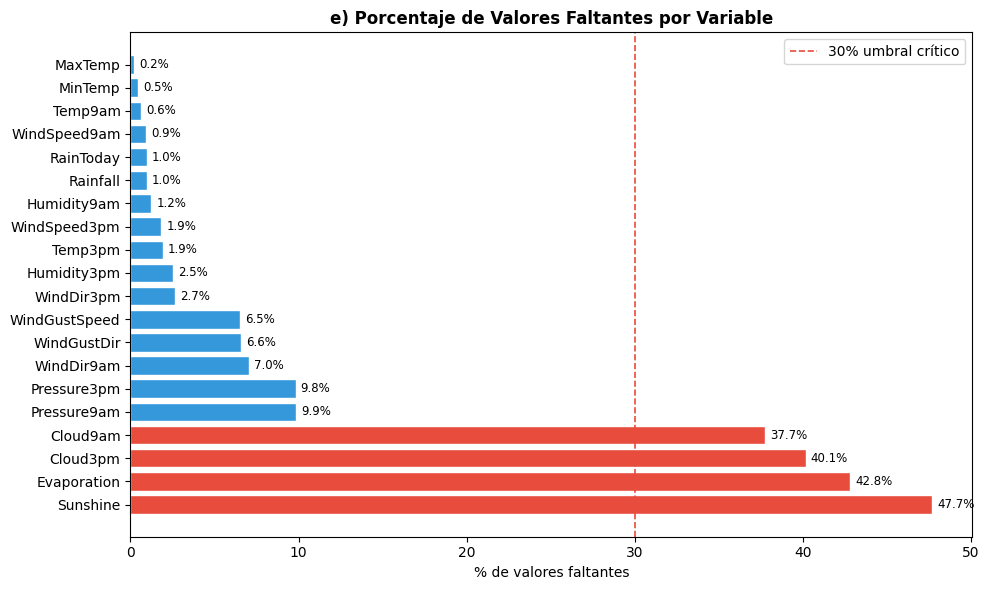

In [9]:
# ==============================================================
# e) VALORES FALTANTES
# ==============================================================
print("\n" + "=" * 60)
print("e) ANÁLISIS DE VALORES FALTANTES")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Nulos": missing, "% Faltante": missing_pct})
missing_df = missing_df[missing_df["Nulos"] > 0].sort_values("% Faltante", ascending=False)
print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
palette = ["#e74c3c" if p > 30 else "#e67e22" if p > 10 else "#3498db"
           for p in missing_df["% Faltante"]]
bars = ax.barh(missing_df.index, missing_df["% Faltante"], color=palette, edgecolor="white")
for bar, pct in zip(bars, missing_df["% Faltante"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center", fontsize=8.5)
ax.axvline(30, color="#e74c3c", linestyle="--", linewidth=1.2, label="30% umbral crítico")
ax.set_xlabel("% de valores faltantes")
ax.set_title("e) Porcentaje de Valores Faltantes por Variable", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("e_faltantes.png", bbox_inches="tight")
plt.show()


R: Las variables con mayor cantidad de datos nulos son **Sunshine (47.69%)**, **Evaporation (42.79%)**, **Cloud3pm (40.15%)** y **Cloud9am (37.74%)**. Estas superan el 30% de datos faltantes, lo que las convierte en críticas y sugieren un problema de recolección sistemático.

**Implicaciones para el Análisis Posterior:**

1.  **Reducción de la Muestra Efectiva:** Un alto porcentaje de valores faltantes reduce la cantidad de datos disponibles para el análisis, lo que puede afectar la representatividad de la muestra y la capacidad de generalizar los resultados.

2.  **Impacto en Algoritmos de Machine Learning:** Muchos algoritmos de machine learning no pueden trabajar directamente con valores nulos, lo que requiere técnicas de imputación o la eliminación de las variables o filas afectadas.

3.  **Dificultad en la Modelación:** Las variables con alta cantidad de nulos (`Sunshine`, `Evaporation`, `Cloud3pm`, `Cloud9am`) son problemáticas. Por ejemplo, eliminar directamente estas columnas es una opción, pero también se pierde información potencialmente valiosa. Imputar tantos valores puede introducir un ruido considerable o suposiciones erróneas en el dataset.

4.  **Sesgo de recolección:** el hecho de que el 50% de los datos de Sunsine y Evaporation sean nulos sugiere que algunas estaciones meteorológicas pueden no contar con el equipo para medir estas variables, obligando a decidir entre trabajar con una muestra sesgada o descartas variables.


F) Identifique posibles valores atípicos (outliers) utilizando diagramas de caja (box-
plots). ¿En qué variables se observan y qué impacto podrían tener en el análisis y  modelamiento?


f) IDENTIFICACIÓN DE OUTLIERS (Boxplots)


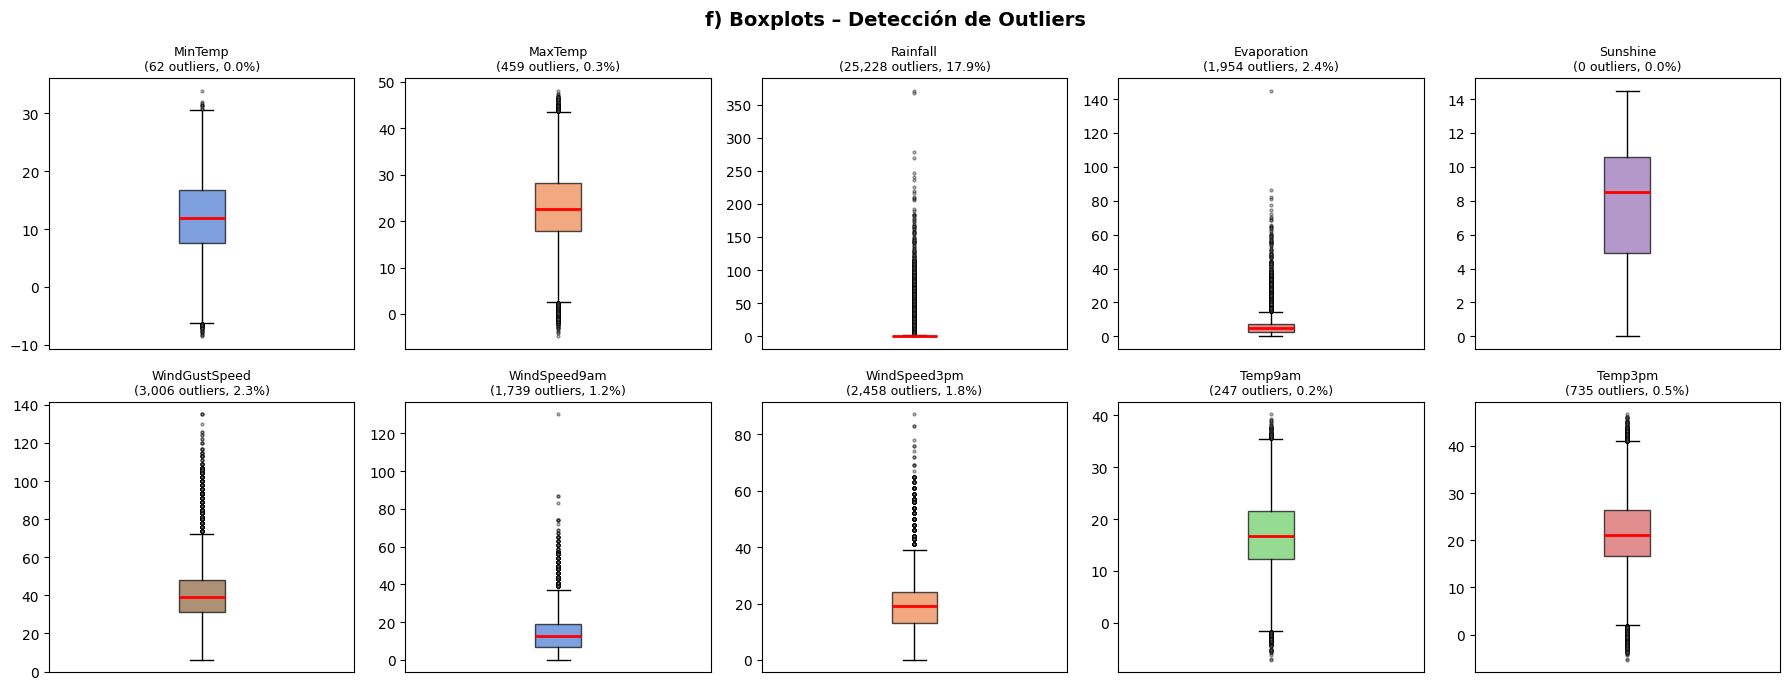


Resumen de outliers:
               N outliers  % outliers
Rainfall          25228.0       17.92
Evaporation        1954.0        2.40
WindGustSpeed      3006.0        2.26
WindSpeed3pm       2458.0        1.76
WindSpeed9am       1739.0        1.23
Temp3pm             735.0        0.53
MaxTemp             459.0        0.32
Temp9am             247.0        0.17
MinTemp              62.0        0.04
Sunshine              0.0        0.00


In [10]:
# ==============================================================
# f) BOXPLOTS – VALORES ATÍPICOS
# ==============================================================
print("\n" + "=" * 60)
print("f) IDENTIFICACIÓN DE OUTLIERS (Boxplots)")
print("=" * 60)

vars_box = ["MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine",
            "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm", "Temp9am", "Temp3pm"]
vars_box = [v for v in vars_box if v in df.columns]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

outlier_summary = {}
for i, var in enumerate(vars_box):
    col = df[var].dropna()
    Q1, Q3 = col.quantile(0.25), col.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((col < Q1 - 1.5 * IQR) | (col > Q3 + 1.5 * IQR)).sum()
    pct = n_outliers / len(col) * 100
    outlier_summary[var] = {"N outliers": n_outliers, "% outliers": round(pct, 2)}

    bp = axes[i].boxplot(col, patch_artist=True, notch=False,
                         boxprops=dict(facecolor=sns.color_palette("muted")[i % 6], alpha=0.7),
                         medianprops=dict(color="red", linewidth=2),
                         flierprops=dict(marker="o", markerfacecolor="gray", markersize=2, alpha=0.4))
    axes[i].set_title(f"{var}\n({n_outliers:,} outliers, {pct:.1f}%)", fontsize=9)
    axes[i].set_xticks([])

plt.suptitle("f) Boxplots – Detección de Outliers", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("f_boxplots.png", bbox_inches="tight")
plt.show()

print("\nResumen de outliers:")
out_df = pd.DataFrame(outlier_summary).T.sort_values("% outliers", ascending=False)
print(out_df.to_string())

R: Se observan valores atípicos (outliers) en varias variables, siendo especialmente notables en:

*   **Rainfall (17.92% de los datos):** La variable con el mayor porcentaje de outliers. Esto indica que la gran mayoría de los días no llueve o llueve muy poco, pero existen eventos de lluvia extremadamente intensos que se desvían significativamente del patrón común. Estos valores extremos son consistentes con la asimetría positiva observada en el histograma. El hecho de que tenga casi un 18% de outliers confirma que la tecnica IQR falla al trata de definir qué es normal en un clima variable como Australia.

*   **Evaporation (2.40% de los datos):** Presenta un porcentaje menor de outliers, pero aún significativo, sugiriendo eventos de evaporación muy alta o baja que se salen de lo común.
*   **WindGustSpeed (2.26% de los datos):** Indica la presencia de ráfagas de viento excepcionalmente fuertes.
*   **WindSpeed3pm (1.76%) y WindSpeed9am (1.23%):** También muestran outliers, aunque en menor medida que la velocidad de las ráfagas.

**Impacto en el Análisis y Modelado:**

1.  **Medidas de Tendencia Central y Dispersión:** Los outliers pueden distorsionar significativamente la media y la desviación estándar. Por ejemplo, la media de `Rainfall` se verá "arrastrada" por los valores altos, no siendo tan representativa de un día típico de lluvia. La mediana es más robusta en estos casos.

2.  **Modelos Estadísticos y de Machine Learning:**
    *   **Algoritmos Sensibles:** Muchos algoritmos (como la Regresión Lineal, K-Means, o Support Vector Machines) son sensibles a los outliers, ya que estos pueden influir desproporcionadamente en los cálculos de distancias o en la optimización de los modelos. Un outlier puede ser interpretado como un error o una observación de alta importancia, llevando a un modelo sub-óptimo.
    *   **Modelos Robustos:** Otros algoritmos (como los basados en árboles, por ejemplo, Random Forests o Gradient Boosting) son inherentemente más robustos a los outliers, ya que sus decisiones se basan en umbrales y no en la magnitud exacta de los valores.

3.  **Interpretación:** Los outliers pueden representar eventos raros pero importantes (como tormentas severas o sequías extremas) que son relevantes para el problema de predicción de lluvia. Eliminarlos sin un análisis cuidadoso podría llevar a la pérdida de información valiosa, mientras que mantenerlos sin tratamiento podría sesgar los modelos.



G) Analice la frecuencia de las variables categóricas más relevantes mediante gráfi-
cos de barras. ¿Existen clases desbalanceadas? Discuta las implicancias de este fenómeno.


g) FRECUENCIA DE VARIABLES CATEGÓRICAS
  Location: clase más frecuente = Canberra (2.4%), clase menos frecuente = Uluru (1.1%)  → Ratio: 2.2x
  WindGustDir: clase más frecuente = W (7.4%), clase menos frecuente = NNE (4.8%)  → Ratio: 1.5x
  WindDir9am: clase más frecuente = N (8.6%), clase menos frecuente = WSW (5.2%)  → Ratio: 1.7x
  WindDir3pm: clase más frecuente = SE (7.7%), clase menos frecuente = NNE (4.7%)  → Ratio: 1.7x


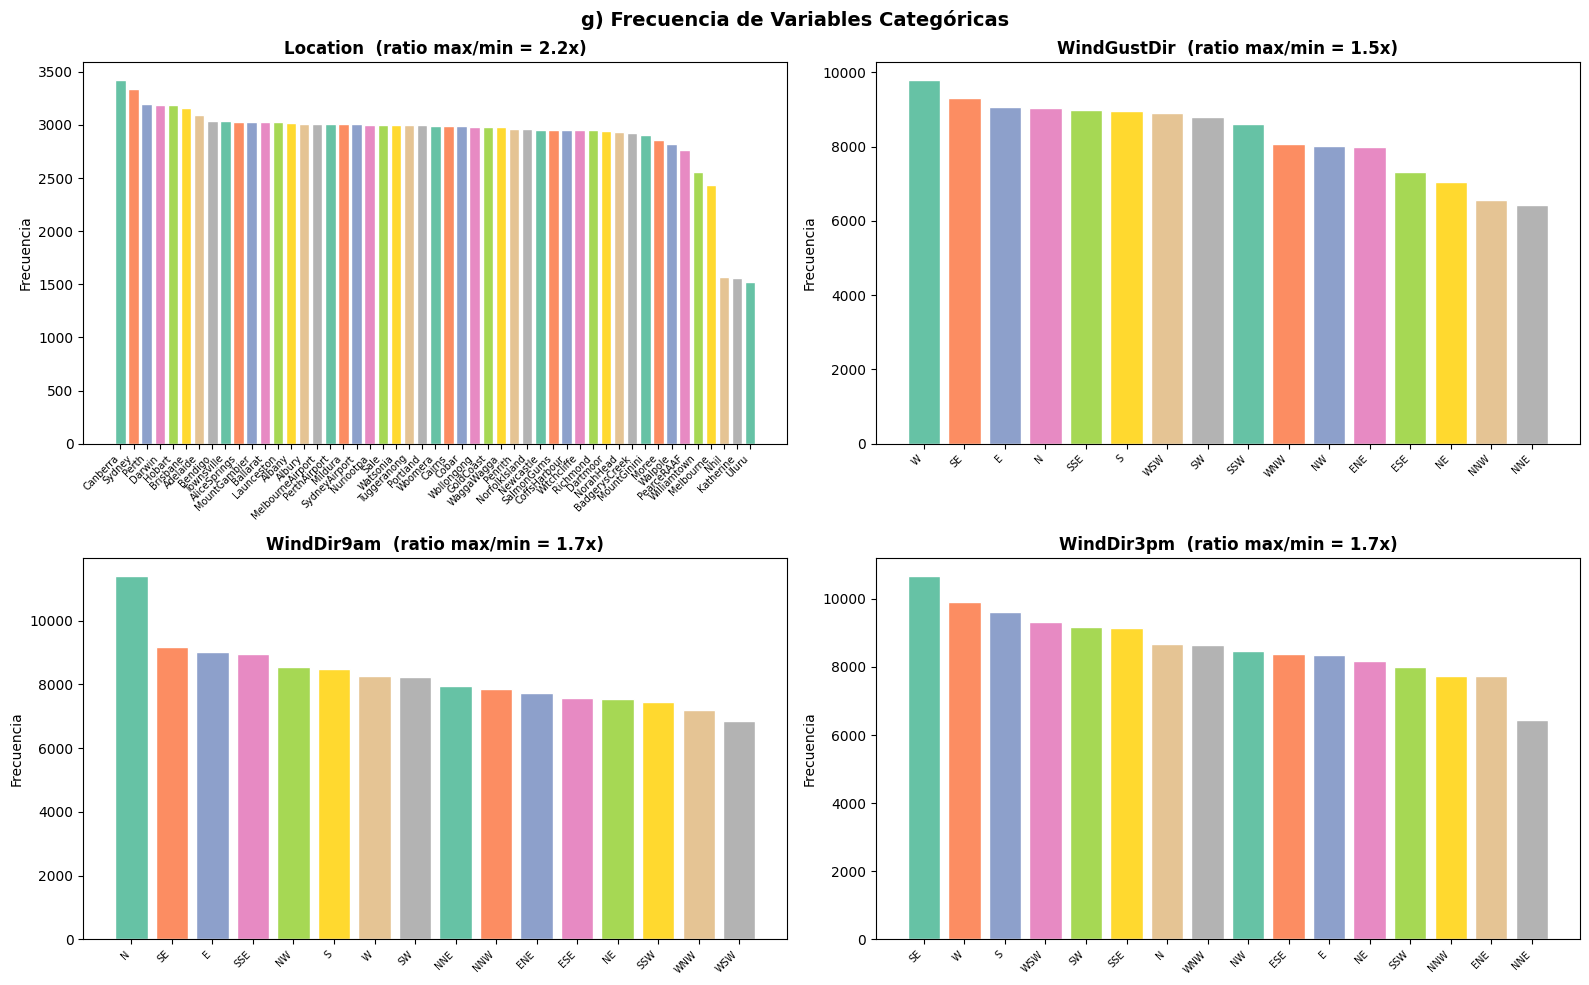

In [11]:
# ==============================================================
# g) VARIABLES CATEGÓRICAS – GRÁFICOS DE BARRAS
# ==============================================================
print("\n" + "=" * 60)
print("g) FRECUENCIA DE VARIABLES CATEGÓRICAS")
print("=" * 60)

cat_cols = ["Location", "WindGustDir", "WindDir9am", "WindDir3pm"]
cat_cols = [c for c in cat_cols if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(cat_cols):
    vc = df[var].value_counts()
    max_pct = vc.iloc[0] / vc.sum() * 100
    min_pct = vc.iloc[-1] / vc.sum() * 100
    ratio = vc.iloc[0] / vc.iloc[-1]

    axes[i].bar(range(len(vc)), vc.values,
                color=sns.color_palette("Set2", len(vc)), edgecolor="white")
    axes[i].set_xticks(range(len(vc)))
    axes[i].set_xticklabels(vc.index, rotation=45, ha="right", fontsize=7)
    axes[i].set_title(f"{var}  (ratio max/min = {ratio:.1f}x)", fontweight="bold")
    axes[i].set_ylabel("Frecuencia")
    print(f"  {var}: clase más frecuente = {vc.idxmax()} ({max_pct:.1f}%), "
          f"clase menos frecuente = {vc.idxmin()} ({min_pct:.1f}%)  → Ratio: {ratio:.1f}x")

plt.suptitle("g) Frecuencia de Variables Categóricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("g_categoricas.png", bbox_inches="tight")
plt.show()


### Interpretación del Desbalance en Variables Categóricas

Las variables categóricas como Location, WindGustDir, WindDir9am y WindDir3pm muestran ciertos niveles de desbalance, aunque no tan extremos como el observado en la variable objetivo RainTomorrow.

*   **Location:** La relación entre la clase más frecuente (Canberra, 2.4%) y la menos frecuente (Uluru, 1.1%) es de 2.2x. Esto indica que hay lugares con significativamente más registros que otros lo cual es esperado por la antiguedad o densidad de las estaciones. Sin embargo destaca la altar cadinalidad de esta variable con 49 ubicaciones distintas, indicando que aunque el desbalance es bajo, la información se fragmenta en muchos grupos pequeños, donde cada ciudad representa apenas un 2% del total de datos.

*   **WindGustDir, WindDir9am, WindDir3pm:** Las direcciones del viento también muestran un desbalance, con ratios entre 1.5x y 1.7x. Esto sugiere que ciertas direcciones del viento son más prevalentes en Australia, lo cual es geográficamente y meteorológicamente coherente.

**Implicaciones para el Análisis y Modelado:**

1.  **Representatividad de Clases:** Las clases con muy pocas observaciones (como Uluru en Location) podrían no estar lo suficientemente representadas para extraer patrones robustos o para que los modelos aprendan de ellas de manera efectiva.

2.  **Modelos de Machine Learning:**
    *   **Codificación:** Al aplicar técnicas de codificación como One-Hot Encoding, las categorías minoritarias generarán columnas con muy pocos unos, lo que podría no ser útil para algunos algoritmos o incluso introducir ruido si no se manejan adecuadamente.
    *   **Sesgo del Modelo:** Un modelo podría sesgarse hacia las categorías más frecuentes si no se aplican técnicas para mitigar el desbalance, resultando en un rendimiento deficiente para predecir o analizar las clases minoritarias.


H) Seleccione una variable objetivo (por ejemplo, RainTomorrow) Analice la distri-
bución de frecuencias de la variable ¿El problema corresponde a una clasificación balanceada o desbalanceada? Justifique.


h) DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (RainTomorrow)
RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64
RainTomorrow
No     77.58
Yes    22.42
Name: proportion, dtype: float64

  Ratio de desbalance: 3.46:1


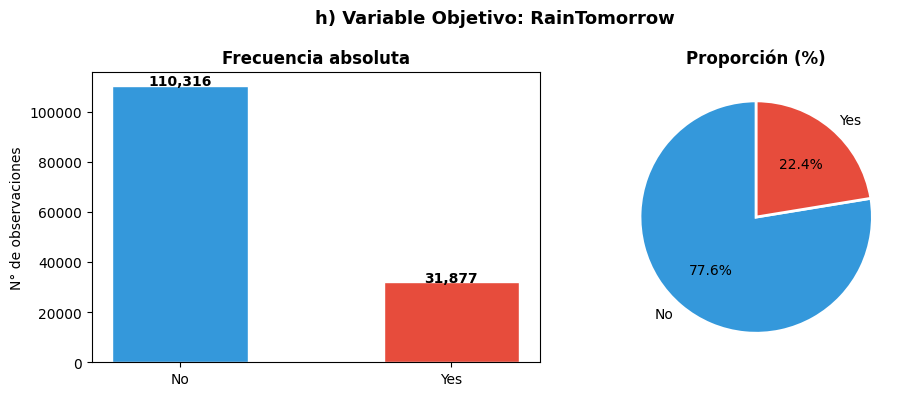

In [12]:
# ==============================================================
# h) VARIABLE OBJETIVO – RainTomorrow
# ==============================================================
print("\n" + "=" * 60)
print("h) DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (RainTomorrow)")
print("=" * 60)

target = "RainTomorrow"
if target in df.columns:
    vc_target = df[target].value_counts()
    vc_pct    = df[target].value_counts(normalize=True) * 100
    print(vc_target)
    print(vc_pct.round(2))

    ratio_desbalance = vc_target.iloc[0] / vc_target.iloc[1]
    print(f"\n  Ratio de desbalance: {ratio_desbalance:.2f}:1")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.bar(vc_target.index, vc_target.values,
            color=["#3498db", "#e74c3c"], edgecolor="white", width=0.5)
    for bar, val in zip(ax1.patches, vc_target.values):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 f"{val:,}", ha="center", fontsize=10, fontweight="bold")
    ax1.set_title("Frecuencia absoluta", fontweight="bold")
    ax1.set_ylabel("N° de observaciones")

    ax2.pie(vc_pct.values, labels=vc_pct.index,
            colors=["#3498db", "#e74c3c"],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
    ax2.set_title("Proporción (%)", fontweight="bold")

    plt.suptitle(f"h) Variable Objetivo: {target}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("h_objetivo.png", bbox_inches="tight")
    plt.show()

R: **El problema de clasificación es DESBALANCEADO.**

**Justificación:**
La variable objetivo RainTomorrow muestra un claro desbalance entre sus clases:

*   La clase "No" (no lloverá mañana) tiene 110,316 ocurrencias, representando el **77.58%** del total.
*   La clase "Yes" (sí lloverá mañana) tiene 31,877 ocurrencias, representando el **22.42%** del total.

Esto resulta en un **ratio de desbalance de 3.46:1**, lo que significa que la clase mayoritaria ("No") es casi 3.5 veces más frecuente que la clase minoritaria ("Yes").
Este desbalance es coherente con la naturaleza del fenómeno climatico donde los días sin luvvia son la condicion meteorológica predominante, mientras que los eventos de precipitación son menos frecuentes.


**Implicaciones:**

1.  **Métricas Engañosas:** Un modelo podría alcanzar una alta precisión (accuracy) simplemente prediciendo siempre la clase mayoritaria ("No"). Por ejemplo, si un modelo predice siempre "No", tendría una precisión del 77.58%, pero sería completamente inútil para predecir cuándo realmente lloverá.

2.  **Sesgo del Modelo:** Los algoritmos de machine learning tienden a optimizarse para la clase mayoritaria, ya que hay más ejemplos de ella. Esto puede llevar a que el modelo ignore o tenga un rendimiento deficiente en la detección de la clase minoritaria, que a menudo es la de mayor interés (en este caso, predecir la lluvia).

3.  **Dificultad para Aprender:** La escasez de ejemplos de la clase minoritaria dificulta que el modelo aprenda sus patrones distintivos, lo que puede resultar en una baja recall (capacidad de detectar todos los casos positivos) y baja precisión (proporción de predicciones positivas correctas) para esa clase.


**i ) Construya la matriz de correlación entre las variables numéricas del dataset (por
ejemplo, utilizando el coeficiente de Pearson). Presente el resultado mediante un
mapa de calor (heatmap)**


i) MATRIZ DE CORRELACIÓN (Pearson)


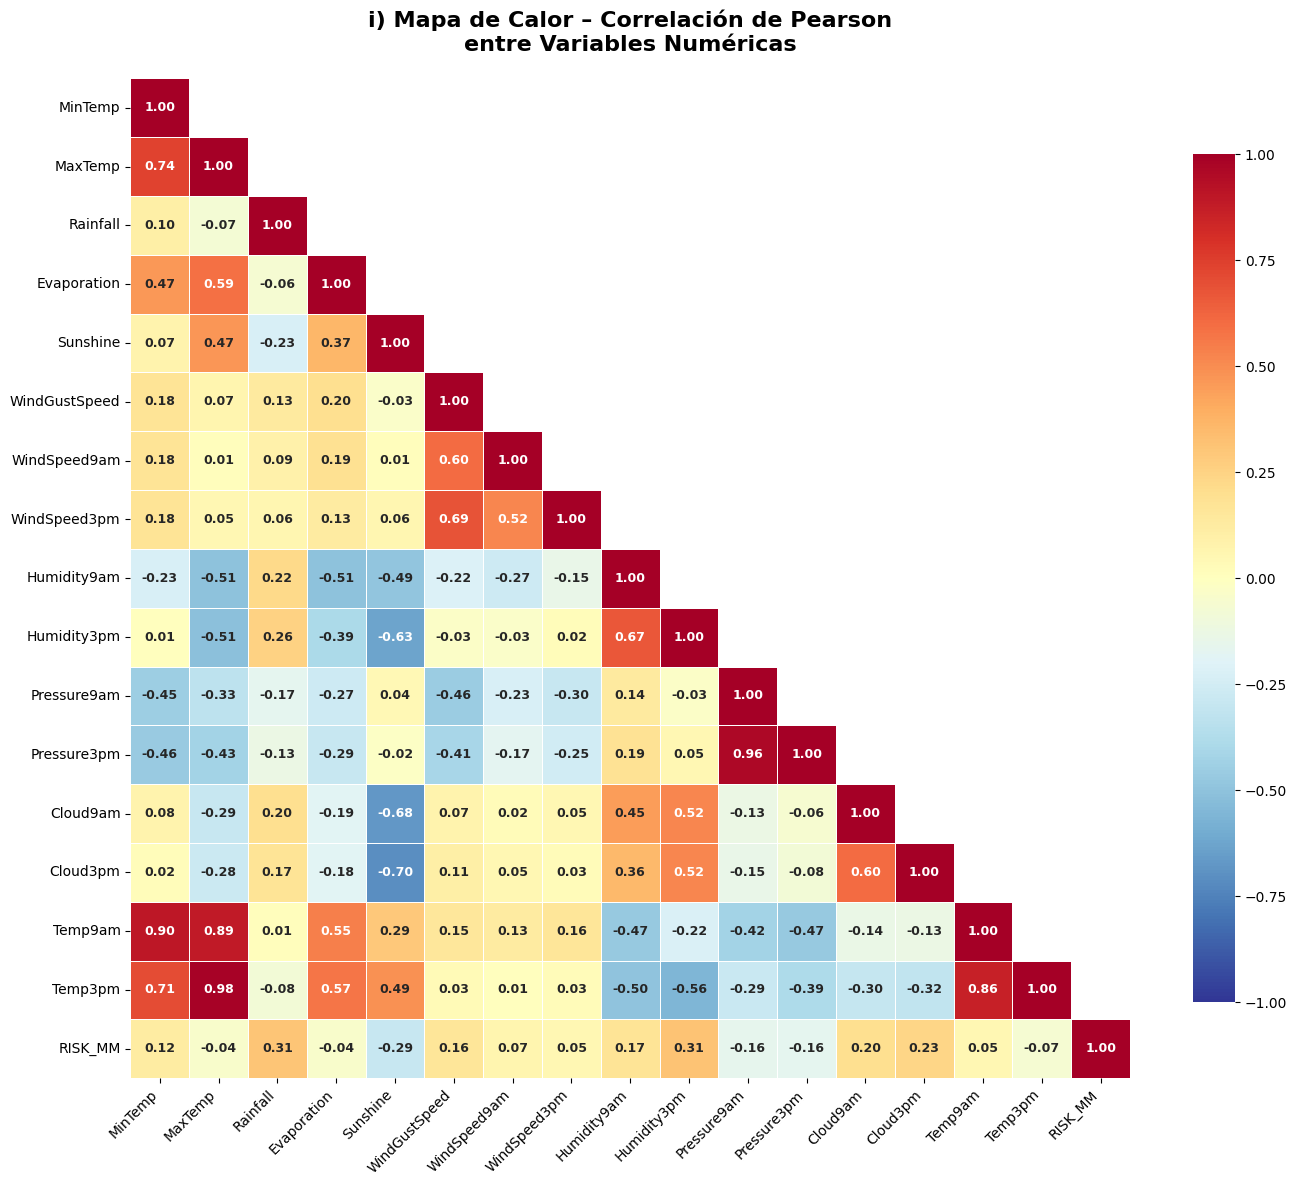

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================================================
# i) MATRIZ DE CORRELACIÓN – HEATMAP (OPTIMIZADO)
# ==============================================================
print("\n" + "=" * 60)
print("i) MATRIZ DE CORRELACIÓN (Pearson)")
print("=" * 60)

# 1. Aseguramos que el lienzo esté limpio para evitar "fantasmas" de plots anteriores
plt.clf()
plt.close('all')

# 2. Preparación de datos
num_df = df[num_cols].copy()
corr_matrix = num_df.corr(method="pearson")

# 3. Ajuste de la Máscara
# Usamos k=1 para ocultar el triángulo superior PERO mantener la diagonal principal (opcional)
# Si prefieres ocultar también la diagonal de 1.0s, deja np.triu como tenías.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# 4. Configuración del gráfico
fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r", # Rojo para positivo, Azul para negativo
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9, "weight": "bold"}, # Números un poco más grandes y legibles
    ax=ax
)

# 5. Estética de etiquetas
ax.set_title("i) Mapa de Calor – Correlación de Pearson\nentre Variables Numéricas",
             fontsize=16, fontweight="bold", pad=20)

# Rotamos etiquetas para evitar que se corten
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("i_heatmap_corregido.png", dpi=300, bbox_inches="tight")
plt.show()

INTERPRETACIÓN:
Al mirar el mapa lo primero que salta a la vista es que el clima de Australia es muy lógico y consistente. Las variables de temperatura tienen una relación casi perfecta por ej: la conexión entre la temperatura máxima (MaxTemp) y la que se registra a las 3 de la tarde (Temp3pm) es de 0.98, lo que nos dice que son prácticamente el mismo dato capturado en momentos distintos. Lo mismo ocurre con la presión atmosférica de la mañana y la tarde que se mueven casi en sincronía.

Esta dependencia nos indica que exite mucha redundancia en la información, lo que significa que los datos estan duplicados.
El gráfico confirma relaciones fisicas naturales (cuando la nubesidad aumenta, el brillo solar cae). De igual forma, cuando la humedad sube, la temperatura suele bajar.

Para que el análisis sea eficiente y claro lo ideal es identificar que variables sobran para no sobrecargar el estudio.

J) **Interprete la matriz de correlación: identifique al menos tres pares de variables
con alta correlación (positiva o negativa). Discuta las implicancias en términos de
multicolinealidad, redundancia de información y estabilidad de los modelos.**


j) PARES CON ALTA CORRELACIÓN (|r| ≥ 0.7)
 Variable 1  Variable 2         r
    Temp3pm     MaxTemp  0.984562
Pressure3pm Pressure9am  0.961348
    Temp9am     MinTemp  0.901813
    Temp9am     MaxTemp  0.887020
    Temp3pm     Temp9am  0.860574
    MaxTemp     MinTemp  0.736267
    Temp3pm     MinTemp  0.708865
   Cloud3pm    Sunshine -0.704202


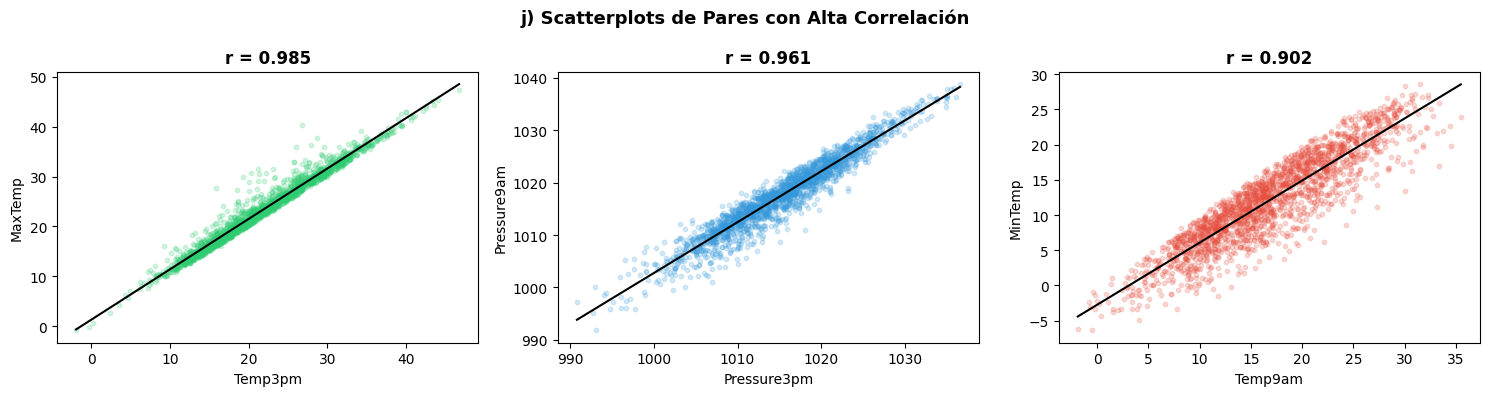

In [14]:
# ==============================================================
# j) INTERPRETACIÓN DE LA MATRIZ DE CORRELACIÓN
# ==============================================================
print("\n" + "=" * 60)
print("j) PARES CON ALTA CORRELACIÓN (|r| ≥ 0.7)")
print("=" * 60)

# Extraer pares sin duplicar
corr_pairs = (
    corr_matrix
    .where(mask == False)
    .stack()
    .reset_index()
)
corr_pairs.columns = ["Variable 1", "Variable 2", "r"]
corr_pairs["abs_r"] = corr_pairs["r"].abs()
high_corr = (
    corr_pairs[corr_pairs["abs_r"] >= 0.7]
    .sort_values("abs_r", ascending=False)
    .reset_index(drop=True)
)

print(high_corr[["Variable 1", "Variable 2", "r"]].to_string(index=False))

# Scatter de los top 3 pares
top_pairs = high_corr.head(3)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_scatter = ["#2ecc71", "#3498db", "#e74c3c"]
for i, (_, row) in enumerate(top_pairs.iterrows()):
    v1, v2, r = row["Variable 1"], row["Variable 2"], row["r"]
    temp_df = df[[v1, v2]].dropna().sample(min(2000, len(df)), random_state=42)
    axes[i].scatter(temp_df[v1], temp_df[v2],
                    alpha=0.2, s=10, color=colors_scatter[i])
    m, b = np.polyfit(temp_df[v1], temp_df[v2], 1)
    x_line = np.linspace(temp_df[v1].min(), temp_df[v1].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color="black", linewidth=1.5)
    axes[i].set_xlabel(v1)
    axes[i].set_ylabel(v2)
    axes[i].set_title(f"r = {r:.3f}", fontweight="bold")

plt.suptitle("j) Scatterplots de Pares con Alta Correlación", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("j_scatter.png", bbox_inches="tight")
plt.show()

### Interpretación de la Matriz de Correlación

**1. Pares con Correlación Muy Alta (positiva, cercana a 1.0):**

*   **Temp3pm y MaxTemp (r = 0.98):** Una correlación extremadamente alta y positiva. Esto significa que la temperatura a las 3 PM es casi directamente proporcional a la temperatura máxima del día. Hay una redundancia muy fuerte: saber una nos dice casi todo sobre la otra. Implica una alta multicolinealidad.
*   **Pressure3pm y Pressure9am (r = 0.96):** Similar al caso anterior, la presión atmosférica a las 9 AM y a las 3 PM están muy relacionadas. Esto sugiere que los cambios en la presión suelen ser consistentes a lo largo del día o que la presión no varía drásticamente en un corto periodo. También indica una alta multicolinealidad.
*   **Temp9am y MinTemp (r = 0.90):** La temperatura a las 9 AM está fuertemente correlacionada con la temperatura mínima del día. Esto también introduce multicolinealidad.

**Implicaciones de estas altas correlaciones positivas:**

*   **Multicolinealidad:** Cuando dos o más variables predictoras en un modelo están altamente correlacionadas, se dice que existe multicolinealidad. Esto es común en datasets meteorológicos donde variables como las temperaturas o presiones en diferentes momentos del día están inherentemente relacionadas.
*   **Redundancia de Información:** Estas variables aportan información muy similar al modelo. Si incluimos ambas, el modelo no aprenderá mucho más que con solo una de ellas, y una de las variables podría ser considerada redundante.
*   **Estabilidad de los Modelos (particularmente en regresión lineal):** En modelos lineales, la multicolinealidad puede inflar la varianza de los coeficientes de regresión, haciéndolos inestables y difíciles de interpretar. Pequeños cambios en los datos de entrada pueden llevar a grandes cambios en los coeficientes. Esto reduce la fiabilidad de las inferencias sobre la importancia individual de cada predictor.

**2. Par con Correlación Negativa Moderada-Alta:**

*   **Cloud3pm y Sunshine (r = -0.70):** Una correlación negativa significativa. Esto es muy lógico: a mayor cobertura de nubes (Cloud3pm), menor cantidad de sol (Sunshine), y viceversa. Indica que estas variables se mueven en direcciones opuestas de manera predecible.

**Implicaciones:**

*   Aunque es una relación fuerte, al ser negativa, también puede indicar multicolinealidad. Si la multicolinealidad es muy alta (cercana a -1 o 1), las implicaciones en la estabilidad y redundancia son las mismas que con correlaciones positivas altas.




K)
### Conclusiones y Acciones de Preprocesamiento del EDA

Después de realizar el Análisis Exploratorio de Datos (EDA), podemos resumir los hallazgos clave y proponer algunas acciones necesarias antes de proceder con el modelado:

**Conclusiones Clave:**

1.  **Distribuciones Asimétricas en Precipitación y Evaporación:** Hemos observado que variables como Rainfall y Evaporation presentan una fuerte asimetría positiva (con una "cola" larga a la derecha). Esto significa que la mayoría de los días tienen valores nulos o muy bajos, pero ocasionalmente ocurren eventos extremos. Esta característica puede sesgar métricas como la media y afectar el rendimiento de algoritmos que asumen una distribución más normal.

2.  **Valores Faltantes Significativos:** Varias columnas, como Sunshine, Evaporation y WindGustDir, contienen un porcentaje considerable de datos faltantes (entre el 10% y más del 40%). Una cantidad tan alta de nulos puede reducir la efectividad de nuestra muestra y potencialmente introducir sesgos si la falta de datos no es aleatoria.

3.  **Desbalance en la Variable Objetivo (RainTomorrow):** La variable que queremos predecir, RainTomorrow (si lloverá mañana), muestra un desbalance importante. Aproximadamente el 77% de las observaciones corresponden a "No" (no lloverá) y solo el 22% a "Sí" (sí lloverá). Este desbalance 3:1 puede llevar a que un modelo prediga mayoritariamente la clase "No" y obtenga una alta precisión aparente, pero sea deficiente detectando los casos reales de lluvia.

**Acciones de Preprocesamiento Recomendadas:**

Para preparar los datos para el modelado, consideramos las siguientes acciones:

A) **Imputación de Valores Faltantes:**
    *   Para las variables numéricas, la imputación por la **mediana** es una opción robusta, ya que es menos sensible a los *outliers* y a las distribuciones asimétricas.
    *   Para las variables categóricas, podemos imputar con la **moda** (el valor más frecuente) o crear una nueva categoría "Unknown" si la ausencia de datos podría ser informativa.
    *   Las columnas con más del 40% de valores faltantes (como Sunshine, Evaporation, Cloud3pm, Cloud9am) deberían ser evaluadas cuidadosamente; podríamos considerar eliminarlas si no se encuentra una estrategia de imputación adecuada o si su impacto en el modelo es mínimo.

B) **Codificación de Variables Categóricas:**
   *   Aplicar **One-Hot Encoding** para variables sin orden (WindGustDir, WindDir9am).
   *   Convertir RainToday/ `RainTomorrow a binario (0/1).

Estas acciones nos permitirán abordar los desafíos identificados y preparar un conjunto de datos limpio y robusto para la siguiente fase de construcción de modelos.